# 07 · Customer Segmentation → Borrower Personas
Unsupervised clustering, then profile each segment by **risk AND profitability** so it drives action: grow the low-risk/high-margin segments, tighten the high-risk ones.

In [1]:
# Make `src` importable when running from the notebooks/ folder
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd, numpy as np
pd.set_option('display.max_columns', 60)

In [2]:
from src.data_loader import load_raw
from src.cleaning import prepare_target
from src import segmentation, config
df = prepare_target(load_raw())
y = df[config.TARGET].to_numpy(); X = df.drop(columns=[config.TARGET])

## Choose k (silhouette)

In [3]:
segmentation.choose_k(X)

,k,silhouette
0,2,0.118581
1,3,0.104612
2,4,0.115575
3,5,0.088011
4,6,0.100340
5,7,0.101673
6,8,0.095257


In [4]:
labels, model, _, _ = segmentation.fit_segments(X, k=4)
profile = segmentation.profile_segments(X, labels, y)
profile

,loan_amount,salary,interest_rate,number_of_defaults,avg_revenue_if_repaid,actual_default_rate,size
segment,,,,,,,
2,37950.837,3447.535,0.218,0.365,8265.973,0.095,36430
1,38083.134,2466.585,0.210,0.536,8004.250,0.119,30475
3,14721.423,2303.363,0.202,0.436,2986.650,0.240,28983
0,34580.861,2592.211,0.210,0.467,7280.688,0.200,4112


## Visualise (2-D PCA)

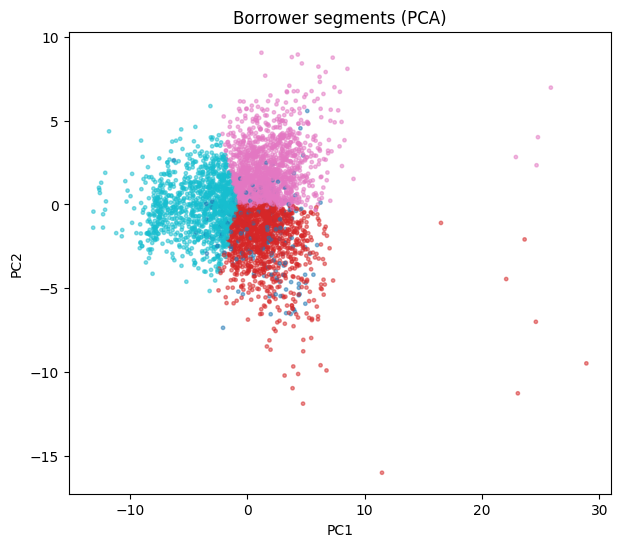

In [5]:
import matplotlib.pyplot as plt
import numpy as np
pcs = segmentation.pca_2d(X)
samp = np.random.RandomState(0).choice(len(pcs), 4000, replace=False)
plt.figure(figsize=(7,6))
plt.scatter(pcs[samp,0], pcs[samp,1], c=np.asarray(labels)[samp], cmap='tab10', s=6, alpha=.5)
plt.title('Borrower segments (PCA)'); plt.xlabel('PC1'); plt.ylabel('PC2');

> **Takeaway:** the high-`actual_default_rate` / low-`avg_revenue` segment is where to tighten policy; the low-risk / high-revenue segment is where to grow. This is the 'who makes us more money' lens you asked for.